# JSE Sector Momentum Strategy — Research Notebook
## Stage 2: Data Collection & Cleaning

### Objective
Download JSE sector index data, identify and fix data quality issues, 
and produce a clean dataset ready for analysis.

### Sectors Collected
- Financials: ^J580.JO — 1,797 rows before gap fill
- Resources: ^J510.JO — 1,817 rows
- Industrials: ^J520.JO — 1,817 rows
- Consumer Goods: ^J530.JO — 1,817 rows

### Data Issues Found and Fixed
1. Financials — 20 missing days (2021-03-23 to 2021-04-21)
   Fix: Downloaded from investing.com, cleaned commas from price 
   column, converted date format, inserted into main dataframe

2. Consumer Goods — single bad data point on 2025-08-20 (value: 10,141)
   Fix: Replaced with linear interpolation using adjacent days
   Result: 100,714 — consistent with surrounding values

3. MultiIndex columns from yfinance
   Fix: Flattened to single level using list comprehension

### Key Decisions Made
- Used outer join on concat to expose all missing dates
- Chose linear interpolation over forward fill for single point errors
- Dropped Property sector — no data available on Yahoo Finance
- Verified Consumer Goods ticker ^J530.JO confirmed on Yahoo Finance

### Output File
data/jse_sector_prices_clean_2019_2026.csv

### Next Step
Stage 3 — Exploratory Data Analysis

# JSE Sector Momentum Strategy
## Step 1 — Indecies Data Collection
Data source: Yahoo Finance via yfinance  
Indicies: Financials, Resources, Industrials and Consumer Goods  
Period: January 2019 to April 2026

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Define our sectors and their Yahoo Finance ticker symbols

sectors = {
    "Financials": "^J580.JO",
    "Resources": "^J510.JO",
    "Industrials": "^J520.JO",
    "Consumer Goods": "^J530.JO"
}




print(sectors)

{'Financials': '^J580.JO', 'Resources': '^J510.JO', 'Industrials': '^J520.JO', 'Consumer Goods': '^J530.JO'}


In [3]:
# Downloading closing prices for all sectors
raw_data = {}

for name, ticker in sectors.items():
    print(f"Downloading {name}...")
    df = yf.download(ticker, start = "2019-01-01", end = "2026-04-10")
    raw_data[name] = df["Close"]

print("Download Complete!")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Download Complete!


In [4]:
for name, data in raw_data.items():
    print(f"{name}: {len(data)} rows, any nulls {data.isnull().any().any()}")

Financials: 1797 rows, any nulls False
Resources: 1817 rows, any nulls False
Industrials: 1817 rows, any nulls False
Consumer Goods: 1817 rows, any nulls False


## Step 2 Gap Filling the Missing Financials Data

In [5]:
#Identify the dates that are missing in the Financials sector compared to the Resources sector
missing_dates = raw_data["Resources"].index.difference(raw_data["Financials"].index)

print(len(missing_dates))
print(missing_dates[:,])

20
DatetimeIndex(['2021-03-23', '2021-03-24', '2021-03-25', '2021-03-26',
               '2021-03-29', '2021-03-30', '2021-03-31', '2021-04-01',
               '2021-04-06', '2021-04-07', '2021-04-08', '2021-04-09',
               '2021-04-12', '2021-04-13', '2021-04-14', '2021-04-15',
               '2021-04-16', '2021-04-19', '2021-04-20', '2021-04-21'],
              dtype='datetime64[s]', name='Date', freq=None)


In [6]:
#Combine all sectors in a dataframe
#Combine with outer join to keep all dates
prices = pd.concat(raw_data, axis=1, join = "outer")

#Check nulls per sector
print("Null counts per sector:")
print(prices.isnull().sum())

#Check which sector has nulls and on what dates
print(prices[prices.isnull().any(axis=1)])


Null counts per sector:
                Ticker  
Financials      ^J580.JO    20
Resources       ^J510.JO     0
Industrials     ^J520.JO     0
Consumer Goods  ^J530.JO     0
dtype: int64
           Financials     Resources   Industrials Consumer Goods
Ticker       ^J580.JO      ^J510.JO      ^J520.JO       ^J530.JO
Date                                                            
2021-03-23        NaN  46405.980469  33788.968750   68141.187500
2021-03-24        NaN  46774.851562  33851.960938   67131.179688
2021-03-25        NaN  46352.109375  33813.750000   67337.226562
2021-03-26        NaN  48627.300781  34914.250000   68744.851562
2021-03-29        NaN  48243.718750  35234.628906   69152.750000
2021-03-30        NaN  48189.820312  35366.898438   69084.882812
2021-03-31        NaN  48030.308594  34546.789062   67739.679688
2021-04-01        NaN  48290.691406  34771.890625   67210.328125
2021-04-06        NaN  49434.378906  35241.441406   68280.492188
2021-04-07        NaN  49279.85156

C:\Users\tatenda\AppData\Local\Temp\ipykernel_44816\2400071256.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  prices = pd.concat(raw_data, axis=1, join = "outer")


In [7]:
financials = raw_data["Financials"]

# Define the gap start (first missing date you found)
gap_start = "2021-03-23"

# Last available date BEFORE the gap
before_gap = financials[financials.index < gap_start].tail(1)

# First available date AFTER the gap
after_gap = financials[financials.index > gap_start].head(1)

print("Before gap:")
print(before_gap[0:])

print("\nAfter gap:")
print(after_gap[0:])

Before gap:
Ticker          ^J580.JO
Date                    
2021-03-19  30828.919922

After gap:
Ticker          ^J580.JO
Date                    
2021-04-22  31129.289062


In [8]:
# Load the gap fill data you prepared from Investing.com
gap_fill = pd.read_csv("data/jse_financials_gap_fill_2021-03-23_2021-04-21_investing.com.csv")
print (gap_fill.shape)
print(gap_fill.dtypes)
print(gap_fill.head())

(20, 7)
Date        str
Price       str
Open        str
High        str
Low         str
Vol.        str
Change %    str
dtype: object
        Date      Price       Open       High        Low    Vol. Change %
0  21/4/2021  30,921.96  31,170.36  31,170.36  30,670.58  64.19M   -0.42%
1  20/4/2021  31,053.73  31,497.46  31,709.06  30,995.85  73.62M   -2.07%
2  19/4/2021  31,709.06  31,722.38  31,845.69  31,511.31  43.30M   -0.17%
3  16/4/2021  31,764.49  31,454.01  31,764.49  31,409.46  65.43M    0.87%
4  15/4/2021  31,489.34  31,149.69  31,503.42  31,045.49  63.46M    1.43%


In [9]:
#Fix date and price columns of the gap fill data
gap_fill["Date"]= pd.to_datetime(gap_fill["Date"],format = "%d/%m/%Y" )
gap_fill["Price"] = gap_fill["Price"].str.replace(",","").astype(float)

#Keep only the date and price columns, rename price to Financials, and set date as index
gap_fill = gap_fill[["Date","Price"]].rename(columns={"Price":"Financials"})
gap_fill = gap_fill.set_index("Date")

print(gap_fill.dtypes)
print(gap_fill)


Financials    float64
dtype: object
            Financials
Date                  
2021-04-21    30921.96
2021-04-20    31053.73
2021-04-19    31709.06
2021-04-16    31764.49
2021-04-15    31489.34
2021-04-14    31045.49
2021-04-13    31060.49
2021-04-12    30964.86
2021-04-09    30876.47
2021-04-08    30620.25
2021-04-07    31074.11
2021-04-06    31221.45
2021-04-01    30984.14
2021-03-31    31243.47
2021-03-30    31955.44
2021-03-29    31709.05
2021-03-26    30955.85
2021-03-25    30194.73
2021-03-24    30366.93
2021-03-23    30362.17


In [10]:
# Fill the gap in the prices dataframe
prices.loc[gap_fill.index, "Financials"] = gap_fill["Financials"]

# Verify the gap is filled
print("Null counts after gap fill:")
print(prices.isnull().sum())

Null counts after gap fill:
                Ticker  
Financials      ^J580.JO    0
Resources       ^J510.JO    0
Industrials     ^J520.JO    0
Consumer Goods  ^J530.JO    0
dtype: int64


# Step 3: Visualising the Data & Identifying Data Errors

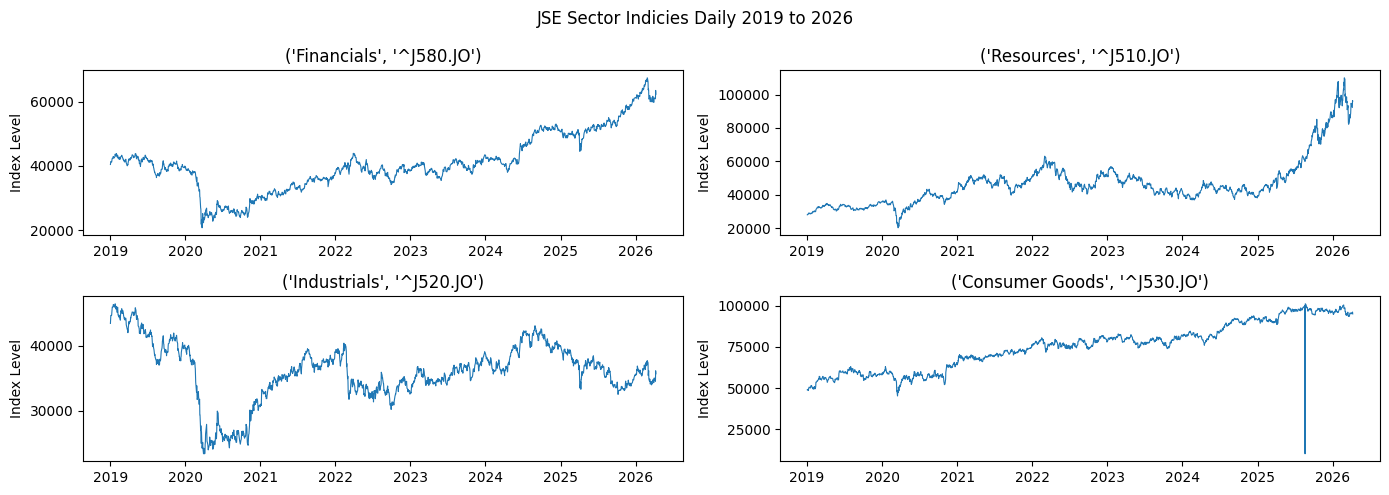

In [11]:
#Plot all four sectors andvisually inpsect for data errors
fig, axes = plt.subplots(2,2,figsize=(14,5))
axes = axes.flatten()
for i, col in enumerate(prices.columns):
    axes[i].plot(prices.index, prices[col], linewidth = 0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel("Index Level")

plt.suptitle("JSE Sector Indicies Daily 2019 to 2026")
plt.tight_layout()
plt.show()

In [12]:
# Flatten the MultiIndex Columns,we will kep only sector names
prices.columns = [col[0] for col in prices.columns]
print(prices.columns)
print(prices.head())

Index(['Financials', 'Resources', 'Industrials', 'Consumer Goods'], dtype='str')
              Financials     Resources   Industrials  Consumer Goods
Date                                                                
2019-01-02  40406.269531  27932.660156  43395.171875    49021.589844
2019-01-03  40985.550781  28209.990234  43877.710938    48981.871094
2019-01-04  41332.500000  28280.140625  44619.699219    49273.308594
2019-01-07  41206.691406  28302.970703  44599.800781    48565.679688
2019-01-08  41161.808594  28446.019531  44689.531250    49551.781250


In [13]:
# Find the suspicious value in Consumer Goods
# Any value below 10,000 is likely wrong given the range
mask = prices["Consumer Goods"] < 20000
print(prices["Consumer Goods"][mask] )

Date
2025-08-20    10141.599609
Name: Consumer Goods, dtype: float64


In [14]:
# Fix the single bad data point using linear interpolation
prices.loc["2025-08-20", "Consumer Goods"] = None

#Interpolate to fill gap
prices["Consumer Goods"] = prices["Consumer Goods"].interpolate(method = "linear")

#Verify the fix
print(prices.loc["2025-08-21", "Consumer Goods"])

print(prices.loc["2025-08-19":"2025-08-21", "Consumer Goods"])

101209.796875
Date
2025-08-19    100218.601562
2025-08-20    100714.199219
2025-08-21    101209.796875
Name: Consumer Goods, dtype: float64


## Step 4: Save Clean Indicies Data

In [15]:
prices.to_csv("data/jse_sector_prices_clean_2019_2026.csv")

print(f"Saved {prices.shape[0]} rows and {prices.shape[1]} columns")
print(prices.tail())

Saved 1817 rows and 4 columns
              Financials     Resources   Industrials  Consumer Goods
Date                                                                
2026-04-01  61118.000000  94813.500000  35028.300781    95119.101562
2026-04-02  61022.578125  94434.000000  34840.101562    95748.101562
2026-04-07  60840.210938  92289.296875  34518.070312    95728.000000
2026-04-08  63447.878906  96451.101562  36128.199219    96215.703125
2026-04-09  62255.898438  96154.796875  35667.031250    95086.703125
